# Chatbot analysis
## Background
I would like to practice some intent recognition on a chatbot.
I will work here with the Bitext-retail-banking-llm-chatbot-training-dataset available through [HuggingFace](https://huggingface.co/datasets/bitext/Bitext-retail-banking-llm-chatbot-training-dataset?utm_source=chatgpt.com).

Unless already done, you must first install huggingface_hub and dataset
> conda install -c huggingface datasets huggingface_hub

> conda install -c huggingface datasets


In [66]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset")
print(dataset["train"][0])
df = dataset["train"].to_pandas()

{'tags': 'BCIPZ', 'instruction': 'I would like to acivate a card, can you help me?', 'category': 'CARD', 'intent': 'activate_card', 'response': 'I\'m here to assist you with that! Activating your card is an important step to starting and enjoying its benefits. Here\'s how you can activate your card:\n\n1. Locate the activation instructions: Depending on the card issuer, you may find the activation instructions on a sticker attached to the card itself, in the welcome package, or on the issuer\'s website.\n\n2. Visit the card issuer\'s activation website: Using your computer or mobile device, open a web browser and navigate to the card issuer\'s website. Look for the activation page or section.\n\n3. Enter the required information: Follow the prompts on the activation page and provide the necessary information. This may include your card number, personal details, and security code.\n\n4. Set up your card: Once you\'ve entered the required information, you may have the option to set up a 

## EDA
Let's first have a look at the dataset.

In [78]:
df.head()

,tags,instruction,category,intent,response,text_length
0,BCIPZ,"I would like to acivate a card, can you help me?",CARD,activate_card,I'm here to assist you with that! Activating y...,11
1,BCILZ,"I have to activate an Visa online, how can I d...",CARD,activate_card,I'm here to assist you with activating your {{...,12
2,BCIPQZ,I'd like to actiate a card where do i do it,CARD,activate_card,I can help you with that! Activating your card...,11
3,BCLPQZ,I'd likke to activate a visa on mobile i need ...,CARD,activate_card,I'm here to assist you with activating your {{...,11
4,BCILPZ,"I would ilke to activate a credit card online,...",CARD,activate_card,I'm here to assist you with activating your cr...,13


In [89]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25545 entries, 0 to 25544
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tags         25545 non-null  object
 1   instruction  25545 non-null  object
 2   category     25545 non-null  object
 3   intent       25545 non-null  object
 4   response     25545 non-null  object
 5   text_length  25545 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.2+ MB


,tags,instruction,category,intent,response,text_length
count,25545,25545,25545,25545,25545,25545.000000
unique,370,25545,9,26,25545,NaN
top,BCIPZ,"I got to set up a apssword, could you help me?",CARD,activate_card,I'd be happy to assist you in setting up a pas...,NaN
freq,818,1,5980,1000,1,NaN
mean,NaN,NaN,NaN,NaN,NaN,11.129967
std,NaN,NaN,NaN,NaN,NaN,2.734339
min,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,NaN,NaN,NaN,9.000000
50%,NaN,NaN,NaN,NaN,NaN,11.000000
75%,NaN,NaN,NaN,NaN,NaN,13.000000


What intents are there? How many different ones? Amd how many each per category?

In [97]:
print("Number of intents:", df["intent"].nunique())
df["intent"].value_counts()

Number of intents: 26


intent
activate_card                        1000
find_branch                          1000
check_recent_transactions             999
human_agent                           999
close_account                         999
customer_service                      998
find_ATM                              998
block_card                            998
activate_card_international_usage     997
apply_for_mortgage                    997
make_transfer                         997
cancel_card                           996
cancel_mortgage                       996
check_card_annual_fee                 996
create_account                        996
cancel_transfer                       995
recover_swallowed_card                994
check_current_balance_on_card         993
apply_for_loan                        992
cancel_loan                           990
check_mortgage_payments               990
check_loan_payments                   989
dispute_ATM_withdrawal                989
check_fees                 

The intents are distributed very evenly. 
There are deviations mainly in intents related to passwords (set_up_password, get_password) and to a lesser extent in check_fees.

Next, the text length should be examined and checked for duplicates.

In [104]:
df["text_length"] = df["instruction"].apply(lambda x: len(x.split()))

df["text_length"].describe()

count    25545.000000
mean        11.129967
std          2.734339
min          2.000000
25%          9.000000
50%         11.000000
75%         13.000000
max         23.000000
Name: text_length, dtype: float64

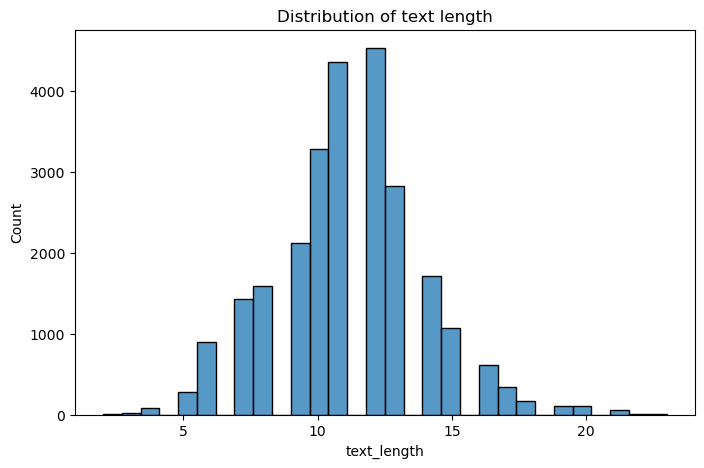

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=30)
plt.title("Distribution of text length")
plt.show()

In [119]:
df.duplicated(subset=["instruction"]).sum()

np.int64(0)

No duplicates, so no need to consider how to deal with them.
Next, what are the most frequent words?
For this, I also used
> conda install -c conda-forge wordcloud

I personally don't think a word cloud gives you too many insights but it's a nice visualization to get a very rough idea of the most frequent words.

In [121]:
from collections import Counter
import re

all_words = " ".join(df["instruction"]).lower()
all_words = re.sub(r"[^\w\s]", "", all_words)

word_counts = Counter(all_words.split())

print(word_counts.most_common(20))

[('i', 27652), ('to', 20150), ('a', 12948), ('it', 10722), ('do', 9122), ('help', 8709), ('me', 7444), ('can', 5639), ('could', 5584), ('need', 5378), ('the', 5352), ('my', 5260), ('like', 5054), ('how', 4560), ('card', 4304), ('for', 4264), ('id', 3838), ('an', 3830), ('where', 3788), ('fucking', 3515)]


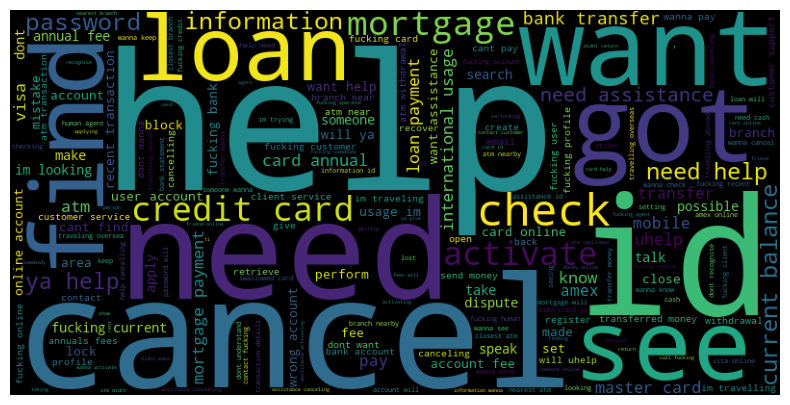

In [122]:
!pip install wordcloud
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

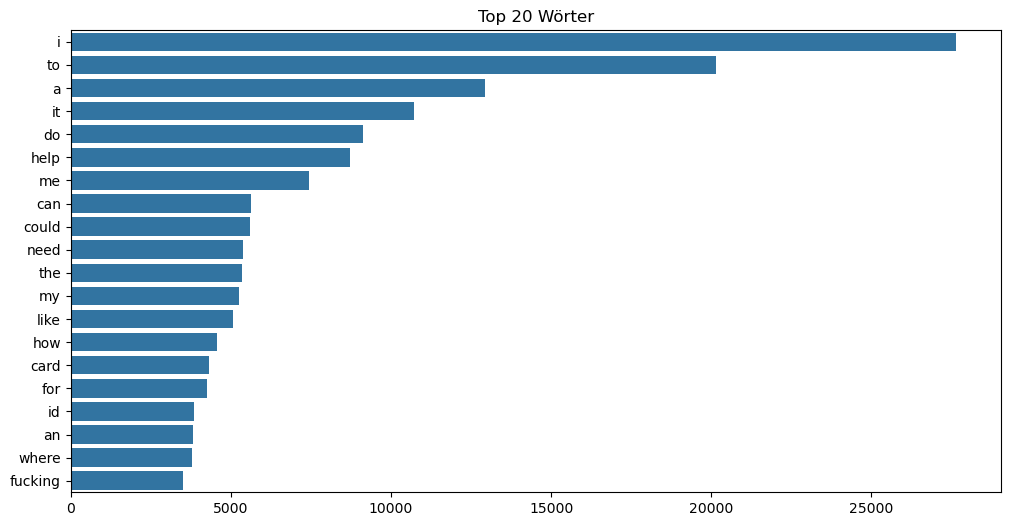

In [126]:
top_words = dict(word_counts.most_common(20))

plt.figure(figsize=(12,6))
sns.barplot(x=list(top_words.values()), y=list(top_words.keys()))
plt.title("Top 20 Wörter")
plt.show()

It may be a bit of a stretch but looking at the 20th most frequent word, the chatbot may not be perfect.

Let's see how if the type of intent affects it length in tokens.

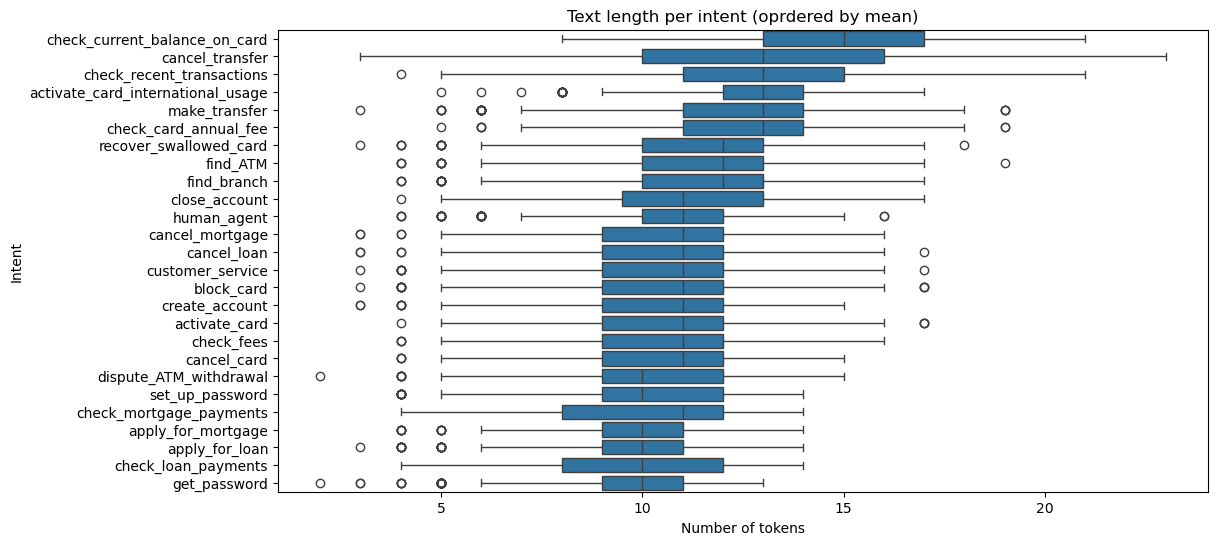

In [129]:
intent_order = df.groupby("intent")["text_length"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="text_length", y="intent", order=intent_order)
plt.title("Text length per intent (oprdered by mean)")
plt.xlabel("Number of tokens")
plt.ylabel("Intent")
plt.show()

As a sanity check, I like to run a term frequency-inverse document frequency (TF-IDF) heatmap of the most common words among the intents.
It shows relative 'importance' of the terms across the dataset.
I used standard stopword removal for English here to remove function words like I, the, and, etc.
This is one way of seeing if the intents are correctly classified.

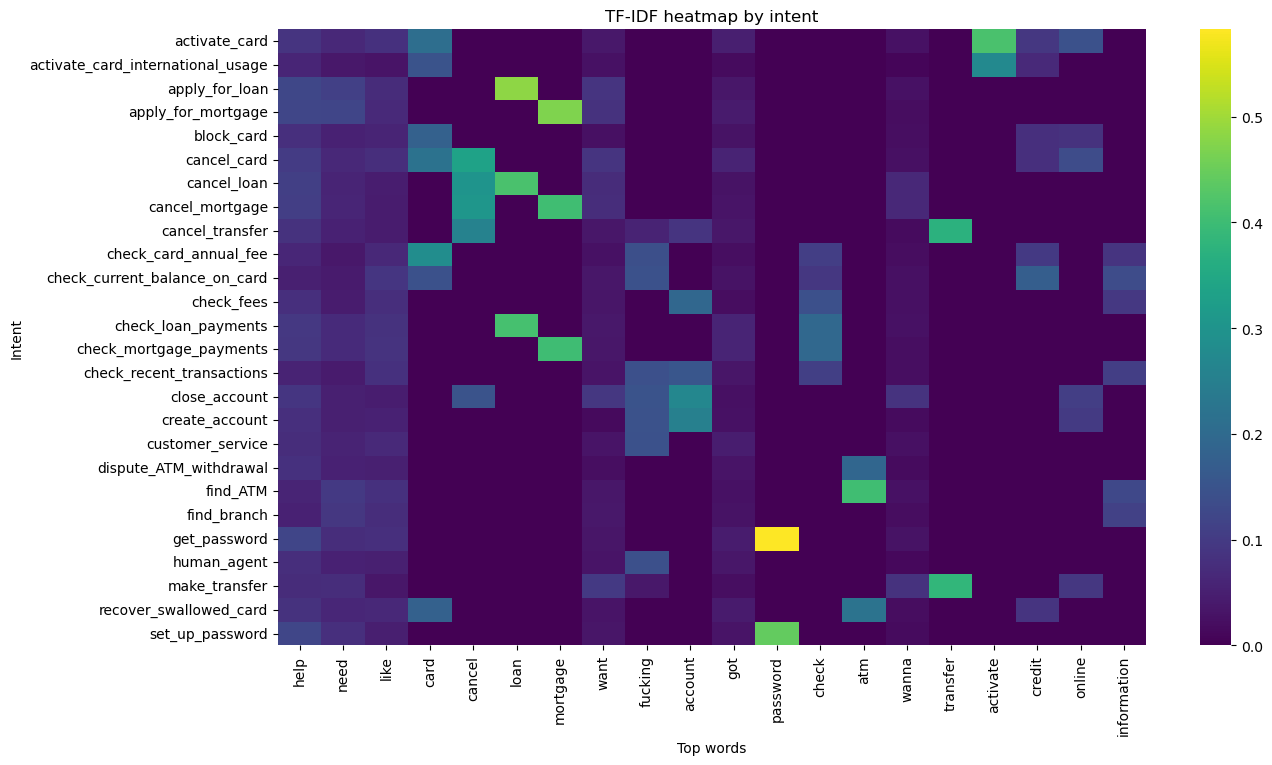

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["instruction"])


# get feature names
feature_names = vectorizer.get_feature_names_out()

# Sparse Matrix -> DataFrame
tfidf_full = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_full["intent"] = df["intent"].values

# mean per intent
intent_tfidf = tfidf_full.groupby("intent").mean()

# global top 20 words by mean TF-IDF
tfidf_means = np.asarray(X.mean(axis=0)).flatten()

tfidf_summary = pd.DataFrame({
    "word": feature_names,
    "mean_tfidf": tfidf_means
})

top_features = (
    tfidf_summary
    .sort_values("mean_tfidf", ascending=False)
    .head(20)["word"]
)

# create heatmap
plt.figure(figsize=(14,8))
sns.heatmap(intent_tfidf[top_features], cmap="viridis")
plt.title("TF-IDF heatmap by intent")
plt.xlabel("Top words")
plt.ylabel("Intent")
plt.show()

And we can see that e.g. "password" comes up most frequently in get_password and set_up_password.
"loan" is most frequent in apply_for_loan, cancel_loan, check_loan_payments.
There are several more interesting things here, such as "cancel", "check", or "atm".
I also think it's worth mentioning that for "help", "need", and "like", no intent stands out, as these words are distributed pretty evenly.

To check differences across intents, it may also be a good idea to use a clustering method, such as PCA or t-SNE, and have a look which intents are closer/more distant to each other

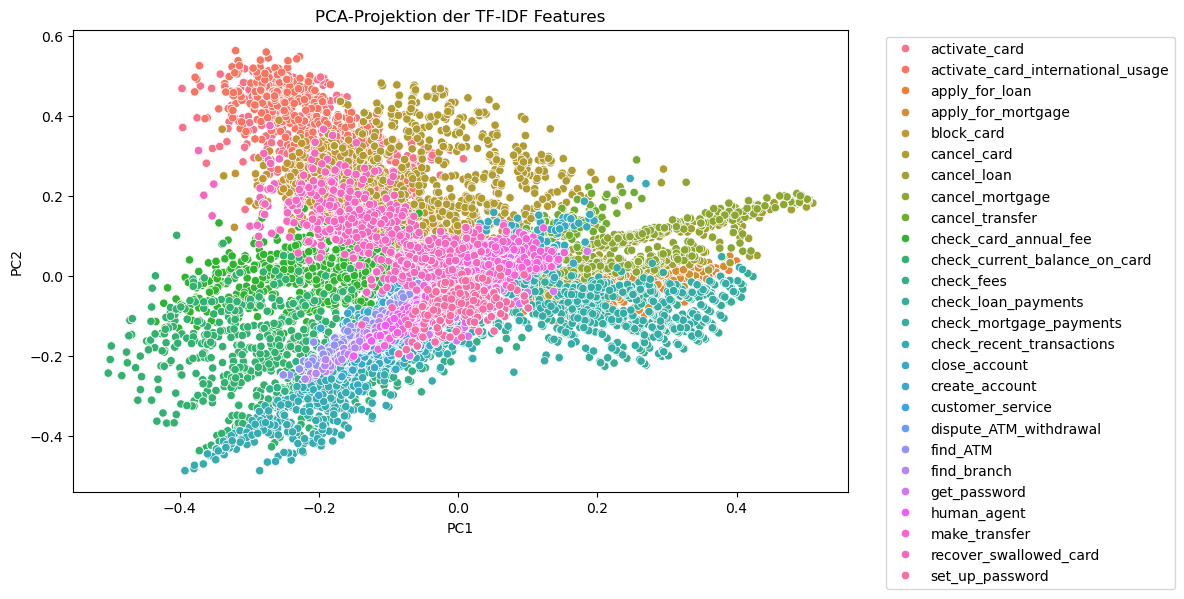

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["intent"], legend=True)
plt.title("PCA projektion of the TF-IDF eatures")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

## ML section
Next, we can load the data set, analyze intentws, do a train/test split, and train a BERT intent classifier on it.
Unless already installed, you may have to use
> pip install datasets transformers torch scikit-learn evaluate
